# SMILES Validator Analysis

In [1]:
import sys
sys.path.insert(0, '..')

from src import validate_smiles, parse_smiles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from collections import Counter

# Validators
from rdkit import Chem
import partialsmiles as ps
import pysmiles
from molvs import validate_smiles as molvs_validate

# Keep per-molecule backend logging out of the comparison output.
import logging
logging.getLogger('pysmiles').setLevel(logging.CRITICAL)
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Parser debugging for SmilesParser written to parser.out


### The validators

- **YACC (original)** — original hand-written validator, *reconstructed* for an old-vs-new comparison (regex aromatic/aliphatic hack + octet valence + heuristic Hückel on the legacy graph).
- **py-yacc-smiles** — our SLY/yacc **grammar** (syntax) + **pysmiles** chemistry backend (valence + aromaticity); pysmiles' string parser bypassed. *Permissive*: accepts hypervalent/radical species RDKit rejects; blocks only impossible valence, unkekulizable aromatics, and malformed syntax.
- **rd-yacc-kit** — same grammar, but **RDKit** chemistry backend (`SanitizeMol`); `MolFromSmiles` bypassed. *Strict*: RDKit-equivalent chemistry behind our stricter syntax gate.
- **PySMILES** — pysmiles end-to-end (`read_smiles`). Contrast with `py-yacc-smiles` to see the value our grammar adds.
- **RDKit**, **PartialSMILES**, **MolVS** — external references.

> ⚠️ **§2 is the trustworthy comparison** — every molecule in `data/*.parquet`.
> §1 (the 126-row hand set) is narrow and its labels were re-aligned to
> py-yacc-smiles' policy, so py-yacc-smiles reads ~100% there *by construction*,
> not as an independent win. Also note these datasets are **RDKit-curated**, so
> RDKit scoring ~100% on §2 is partly circular; the validators truly differ on
> `data/invalid_smiles.parquet` (§2 last panel) and on unusual chemistry.

In [2]:
# Define all validators
import re
from src import parser, lexer, parser_manager
from chem.validator import ChemistryValidator
from chem.adapter import to_descriptor, valid_rdkit

def validate_rdkit(mol):
    try: return Chem.MolFromSmiles(mol) is not None
    except: return False

def validate_partialsmiles(mol):
    try: ps.ParseSmiles(mol, partial=False); return True
    except: return False

def validate_pysmiles(mol):
    # pysmiles end-to-end: its OWN parser AND chemistry (read_smiles).
    try: pysmiles.read_smiles(mol); return True
    except: return False

def validate_molvs(mol):
    try: return len(molvs_validate(mol)) == 0
    except: return False

def validate_py_yacc_smiles(mol):
    # our grammar (syntax) + pysmiles chemistry backend (PERMISSIVE).
    # Bypasses pysmiles.read_smiles. See docs/chemistry_backend_study.md.
    status, _ = validate_smiles(mol)
    return status

def validate_rd_yacc_kit(mol):
    # our grammar (syntax) + RDKit chemistry backend (STRICT, SanitizeMol).
    # Bypasses Chem.MolFromSmiles.
    try:
        ok, g, _ = parse_smiles(mol)
        if not ok: return False
        a, b = to_descriptor(g)
        return bool(valid_rdkit(a, b)[0])
    except Exception:
        return False

_original_chem = ChemistryValidator()

def validate_yacc_original(mol):
    # original hand-written validator, reconstructed (regex hack + octet + Huckel).
    try:
        if re.search(r'C$', mol) and not re.search(r'C\d$', mol) and re.search(r'\d', mol):
            return False
        parser.parse(lexer.tokenize(mol))
        g = parser_manager.graph_builder.get_graph()
        parser_manager.clear()
        ok, _ = _original_chem.validate_rings_and_valency(g)
        if not ok: return False
        ok, _ = _original_chem.validate_aromaticity(g)
        return bool(ok)
    except Exception:
        parser_manager.clear()
        return False

# Order matches analyses/run_full_validation.py and the cached results columns.
VALIDATORS = {
    'YACC (original)': validate_yacc_original,
    'py-yacc-smiles': validate_py_yacc_smiles,
    'rd-yacc-kit': validate_rd_yacc_kit,
    'RDKit': validate_rdkit,
    'PartialSMILES': validate_partialsmiles,
    'PySMILES': validate_pysmiles,
    'MolVS': validate_molvs,
}

In [3]:
hand_test = ["c1cc[c]2c(c1)oc3ccc23"] 

for mol in hand_test:
    print(mol+"\n\n") 
    for name, validator in VALIDATORS.items():
        print(name, validator(mol))



c1cc[c]2c(c1)oc3ccc23


YACC (original) False
py-yacc-smiles True
rd-yacc-kit True
RDKit True
PartialSMILES True
PySMILES True
MolVS True


## 1. Ground Truth Validation (Test Dataset)

In [4]:
test_df = pd.read_parquet('../tests/data/test_molecules_from_values.parquet')
test_df = test_df.dropna(subset=['smiles'])
print(f"Test dataset: {len(test_df)} molecules ({test_df['is_valid'].sum()} valid, {(~test_df['is_valid']).sum()} invalid)")

Test dataset: 126 molecules (110 valid, 16 invalid)


In [5]:
# Run all validators
for name, validator in VALIDATORS.items():
    test_df[name] = test_df['smiles'].apply(validator)
test_df['ground_truth'] = test_df['is_valid']

### Metrics Comparison

In [6]:
def compute_metrics(y_true, y_pred, name):
    tp = ((y_true == True) & (y_pred == True)).sum()
    tn = ((y_true == False) & (y_pred == False)).sum()
    fp = ((y_true == False) & (y_pred == True)).sum()
    fn = ((y_true == True) & (y_pred == False)).sum()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'Validator': name, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Accuracy': f'{accuracy:.2%}', 'Precision': f'{precision:.2%}', 
            'Recall': f'{recall:.2%}', 'F1': f'{f1:.2%}'}

metrics = [compute_metrics(test_df['ground_truth'], test_df[name], name) for name in VALIDATORS]
metrics_df = pd.DataFrame(metrics).sort_values('Accuracy', ascending=False)
display(metrics_df)

,Validator,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
2,rd-yacc-kit,109,16,0,1,99.21%,100.00%,99.09%,99.54%
3,RDKit,109,16,0,1,99.21%,100.00%,99.09%,99.54%
6,MolVS,109,16,0,1,99.21%,100.00%,99.09%,99.54%
4,PartialSMILES,101,16,0,9,92.86%,100.00%,91.82%,95.73%
5,PySMILES,101,16,0,9,92.86%,100.00%,91.82%,95.73%
0,YACC (original),89,11,5,21,79.37%,94.68%,80.91%,87.25%
1,py-yacc-smiles,110,16,0,0,100.00%,100.00%,100.00%,100.00%


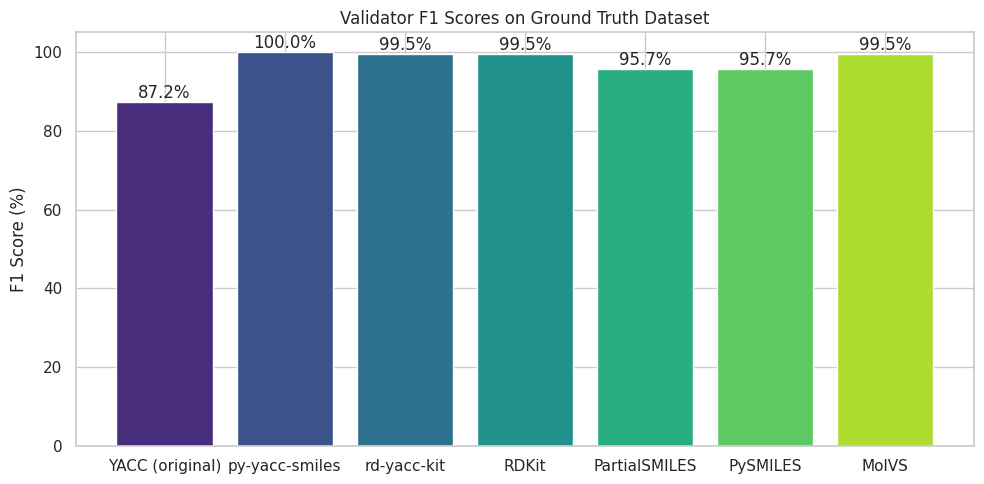

In [7]:
# Bar chart of F1 scores
fig, ax = plt.subplots(figsize=(10, 5))
f1_values = [float(m['F1'].strip('%')) for m in metrics]
colors = sns.color_palette('viridis', len(VALIDATORS))
bars = ax.bar([m['Validator'] for m in metrics], f1_values, color=colors)
ax.set_ylabel('F1 Score (%)')
ax.set_title('Validator F1 Scores on Ground Truth Dataset')
ax.set_ylim(0, 105)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('f1_scores.png', dpi=150)
plt.show()

### Confusion Matrices

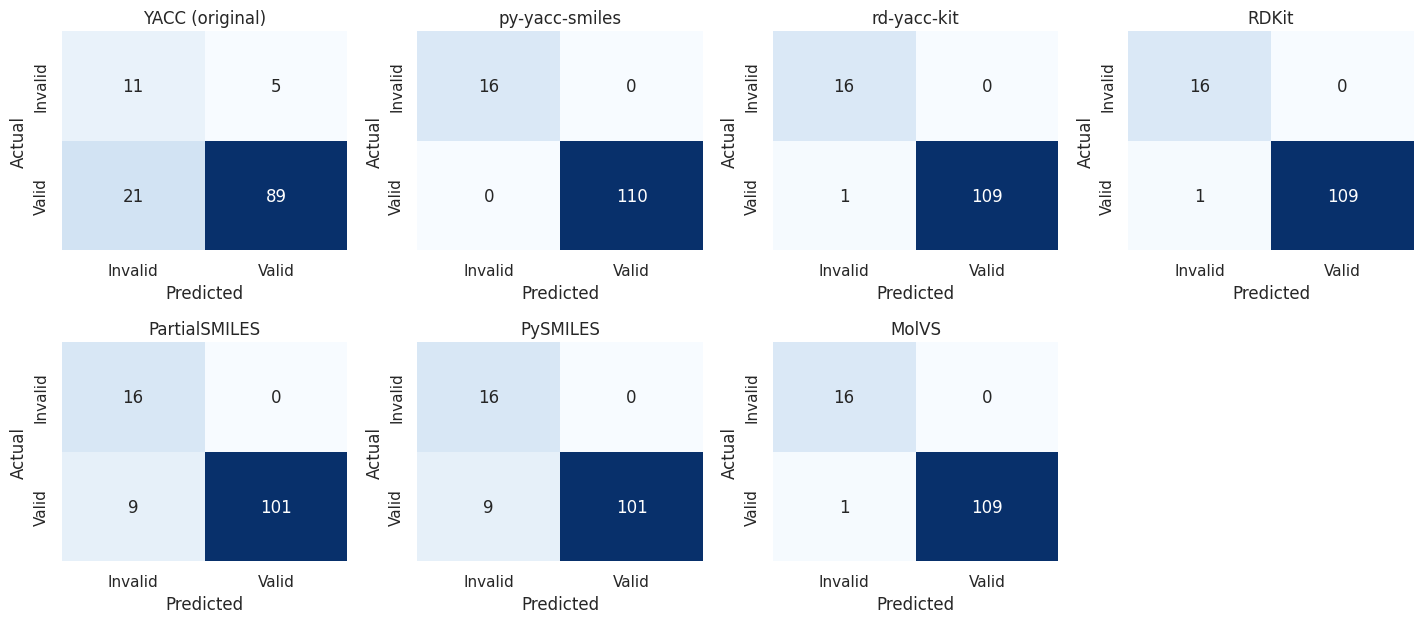

In [8]:
import math
n = len(VALIDATORS)
ncols = 4
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.6 * ncols, 3.2 * nrows))
axes = axes.flatten()
for ax, name in zip(axes, VALIDATORS.keys()):
    cm = pd.crosstab(test_df['ground_truth'], test_df[name],
                     rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xticklabels(['Invalid', 'Valid'])
    ax.set_yticklabels(['Invalid', 'Valid'])
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

### False Positives Table

In [9]:
fp_counts = {name: ((test_df['ground_truth'] == False) & (test_df[name] == True)).sum() for name in VALIDATORS}
fp_df = pd.DataFrame(list(fp_counts.items()), columns=['Validator', 'False Positives']).sort_values('False Positives')
display(fp_df)

print("\nFalse Positives by Validator:")
for name in VALIDATORS:
    fps = test_df[(test_df['ground_truth'] == False) & (test_df[name] == True)]['smiles'].tolist()
    if fps:
        print(f"\n{name} ({len(fps)}):")
        for s in fps[:5]:
            print(f"  {s[:60]}")

,Validator,False Positives
1,py-yacc-smiles,0
2,rd-yacc-kit,0
3,RDKit,0
4,PartialSMILES,0
6,MolVS,0
5,PySMILES,0
0,YACC (original),5



False Positives by Validator:

YACC (original) (5):
  c1cc-[c]2c(=c1)c1=cc=cc3=cc=cc2=c13
  C1=CC2=CC=C3C=CC=C4C=CC(=C43)C=C2
  c1cc2cccc3c4cccc(c(c1)c2c3)c4cc5cccc5
  C1=CC2=C3C(=C1)C=CC=C3C3=C4C(=CC=CC4=CC=C23)C=C2
  c1cc2cccc3c4c[c]cc(c(c1)c2c3)c4cc5cccc5


### False Negatives Table

In [10]:
fn_counts = {name: ((test_df['ground_truth'] == True) & (test_df[name] == False)).sum() for name in VALIDATORS}
fn_df = pd.DataFrame(list(fn_counts.items()), columns=['Validator', 'False Negatives']).sort_values('False Negatives')
display(fn_df)

,Validator,False Negatives
1,py-yacc-smiles,0
2,rd-yacc-kit,1
3,RDKit,1
6,MolVS,1
5,PySMILES,9
4,PartialSMILES,9
0,YACC (original),21


## 2. Full-Dataset Benchmark (every molecule, every dataset)

Every molecule in `data/*.parquet` (~2.25M) validated by all seven validators,
computed once in parallel by `analyses/run_full_validation.py` and cached. Below:
the **JOINT** status across all datasets, then the **PER-DATASET** breakdown, then
pairwise agreement and the known-invalid set.

In [11]:
# Load the full per-molecule results (every molecule, every dataset), produced by
# analyses/run_full_validation.py. If the cache is missing, generate it now
# (parallel across cores; ~15-20 min on a multi-core machine).
import os, subprocess

if not (os.path.exists('full_validation_results.parquet')
        and os.path.exists('invalid_validation_results.parquet')):
    print('Cache missing -> running analyses/run_full_validation.py (~15-20 min)...')
    subprocess.run([sys.executable, 'run_full_validation.py'], check=True)

bench_df = pd.read_parquet('full_validation_results.parquet')
inv_df = pd.read_parquet('invalid_validation_results.parquet')
BV = [c for c in bench_df.columns if c != 'dataset']      # validator columns, in order
counts = bench_df.groupby('dataset', observed=True).size().rename('molecules')

print(f"{len(bench_df):,} molecules across {bench_df['dataset'].nunique()} datasets")
print(f"validators: {BV}")
display(counts.to_frame())

2,252,243 molecules across 9 datasets
validators: ['YACC (original)', 'py-yacc-smiles', 'rd-yacc-kit', 'RDKit', 'PartialSMILES', 'PySMILES', 'MolVS']


,molecules
dataset,
clintox,1484
moses_test,176074
moses_train,1584663
mutagenicity,4337
muv,93087
qm9,133885
sider,1427
tox21,7831
zinc250k,249455


In [12]:
# JOINT acceptance across ALL datasets (real molecules -> higher = fewer valid
# molecules discarded). NB: these datasets are RDKit-curated, so RDKit's ~100%
# is partly circular (see the caveat above).
joint = pd.DataFrame({
    'Accepted': bench_df[BV].sum().astype(int),
    'Total': len(bench_df),
    'Pass Rate (%)': (bench_df[BV].mean() * 100).round(3),
}).sort_values('Pass Rate (%)', ascending=False)
print(f'JOINT acceptance over {len(bench_df):,} molecules (all datasets):')
display(joint)

JOINT acceptance over 2,252,243 molecules (all datasets):


,Accepted,Total,Pass Rate (%)
py-yacc-smiles,2252222,2252243,99.999
rd-yacc-kit,2252226,2252243,99.999
RDKit,2252231,2252243,99.999
PartialSMILES,2251933,2252243,99.986
PySMILES,2235344,2252243,99.250
MolVS,2180412,2252243,96.811
YACC (original),1285744,2252243,57.087


### Per-dataset acceptance (individual datasets)

In [13]:
# PER-DATASET acceptance rate (%) of each validator.
summary = bench_df.groupby('dataset', observed=True)[BV].mean().mul(100).round(2)
summary.insert(0, 'count', counts)
display(summary)

,count,YACC (original),py-yacc-smiles,rd-yacc-kit,RDKit,PartialSMILES,PySMILES,MolVS
dataset,,,,,,,,
clintox,1484,29.92,99.33,99.39,99.73,98.25,93.73,45.75
moses_test,176074,57.02,100.00,100.00,100.00,100.00,100.00,100.00
moses_train,1584663,56.96,100.00,100.00,100.00,100.00,100.00,100.00
mutagenicity,4337,74.64,100.00,100.00,100.00,99.91,99.98,93.13
muv,93087,59.20,100.00,100.00,100.00,100.00,94.74,100.00
qm9,133885,84.74,100.00,100.00,100.00,99.89,100.00,99.76
sider,1427,58.58,100.00,100.00,100.00,96.57,97.41,86.12
tox21,7831,65.75,99.86,99.90,99.90,98.86,97.37,91.83
zinc250k,249455,41.87,100.00,100.00,100.00,100.00,95.32,72.11


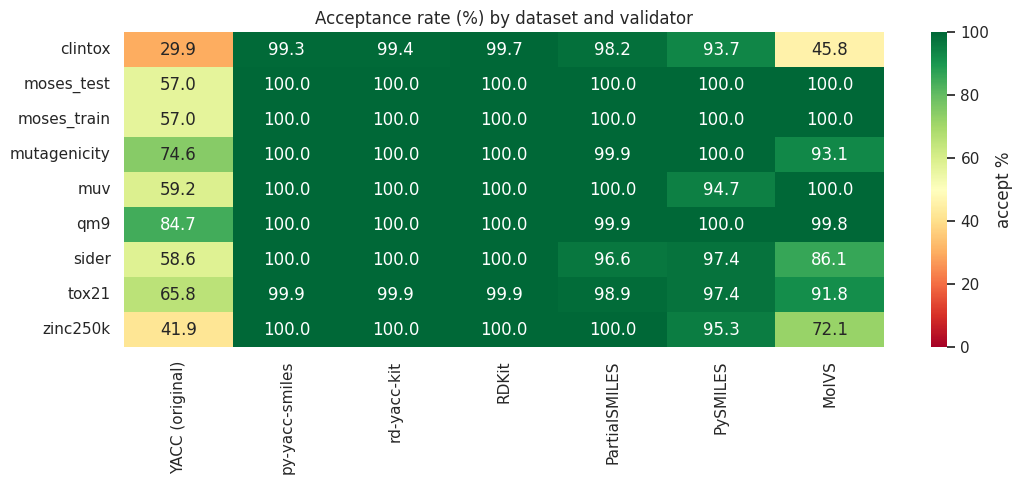

In [14]:
# Per-dataset acceptance heatmap (cleaner than a 7-validator grouped bar)
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(summary[BV], annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100,
            ax=ax, cbar_kws={'label': 'accept %'})
ax.set_title('Acceptance rate (%) by dataset and validator')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('validation_rates.png', dpi=150)
plt.show()

### Joint pass-rate chart (all datasets combined)

In [15]:
# Joint pass-rate (for the bar chart below)
pass_df = joint['Pass Rate (%)'].reset_index()
pass_df.columns = ['Validator', 'Pass Rate (%)']
display(pass_df)

,Validator,Pass Rate (%)
0,py-yacc-smiles,99.999
1,rd-yacc-kit,99.999
2,RDKit,99.999
3,PartialSMILES,99.986
4,PySMILES,99.250
5,MolVS,96.811
6,YACC (original),57.087


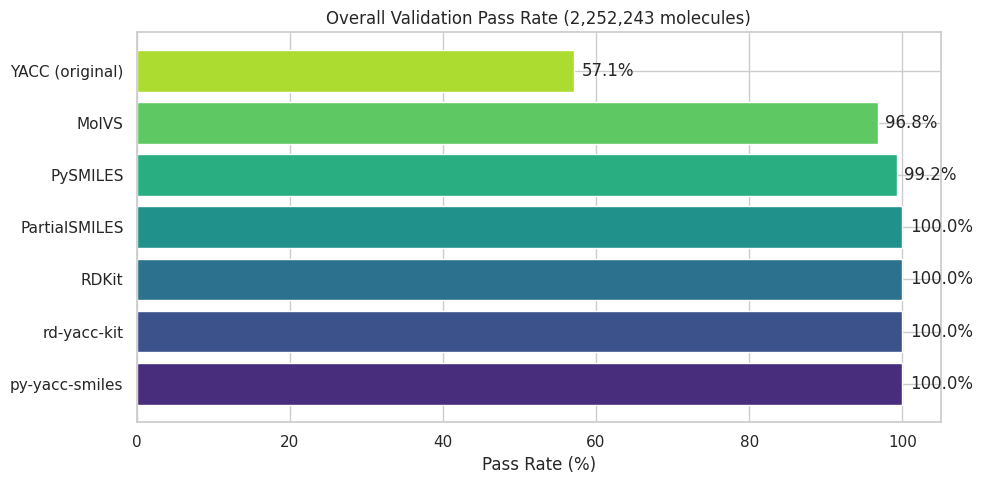

In [16]:
# Horizontal bar chart of pass rates
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('viridis', len(pass_df))
ax.barh(pass_df['Validator'], pass_df['Pass Rate (%)'], color=colors)
ax.set_xlabel('Pass Rate (%)')
ax.set_title(f'Overall Validation Pass Rate ({len(bench_df):,} molecules)')
ax.set_xlim(0, 105)
for i, val in enumerate(pass_df['Pass Rate (%)']):
    ax.text(val + 1, i, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.savefig('pass_rates.png', dpi=150)
plt.show()

### Agreement Heatmap

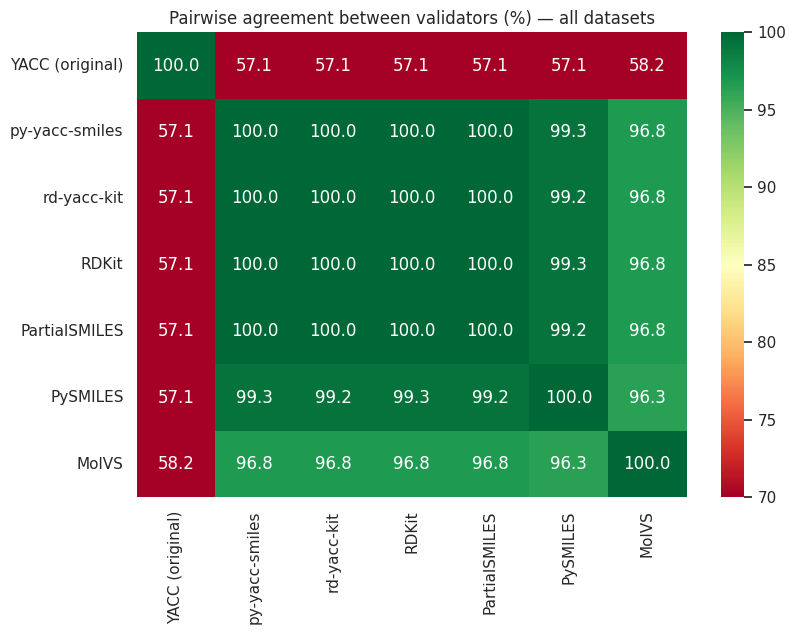

In [17]:
# Pairwise agreement between validators (all molecules, all datasets)
agreement_matrix = pd.DataFrame(index=BV, columns=BV, dtype=float)
for v1 in BV:
    for v2 in BV:
        agreement_matrix.loc[v1, v2] = (bench_df[v1] == bench_df[v2]).mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt='.1f', cmap='RdYlGn',
            ax=ax, vmin=70, vmax=100)
ax.set_title('Pairwise agreement between validators (%) — all datasets')
plt.tight_layout()
plt.savefig('agreement_heatmap.png', dpi=150)
plt.show()

### Known-Invalid Set — rejection by validator (higher = better)

`data/invalid_smiles.parquet` is the one set of *labelled-invalid* molecules, so
here a high **rejection** rate is good. This is where the validators genuinely
differ (the RDKit-curated positive datasets cannot show it).

In [18]:
# Rejection on the labelled-invalid set, overall and by error category.
inv_total = len(inv_df)
overall = pd.DataFrame({
    'Rejected': [int((~inv_df[v]).sum()) for v in BV],
    'of': inv_total,
    'Reject %': [round((~inv_df[v]).mean() * 100, 1) for v in BV],
}, index=BV).sort_values('Reject %', ascending=False)
print(f'Rejection on {inv_total} KNOWN-INVALID molecules (higher = better):')
display(overall)

# Rejected count by error category (n = rows in that category). 'valency' is the
# hypervalent chemistry that py-yacc-smiles accepts by design.
cats = sorted(inv_df['error_category'].unique())
rows = []
for c in cats:
    g = inv_df[inv_df['error_category'] == c]
    row = {'n': len(g)}
    row.update({v: int((~g[v]).sum()) for v in BV})
    rows.append(row)
by_cat = pd.DataFrame(rows, index=cats)
print('\nRejected count by error category:')
display(by_cat)

Rejection on 51 KNOWN-INVALID molecules (higher = better):


,Rejected,of,Reject %
MolVS,46,51,90.2
PartialSMILES,45,51,88.2
rd-yacc-kit,43,51,84.3
YACC (original),42,51,82.4
RDKit,41,51,80.4
py-yacc-smiles,39,51,76.5
PySMILES,29,51,56.9



Rejected count by error category:


,n,YACC (original),py-yacc-smiles,rd-yacc-kit,RDKit,PartialSMILES,PySMILES,MolVS
bad_aromaticity,4,4,2,2,2,2,2,2
bad_ring,1,0,0,0,0,0,0,0
dangling_bond,3,3,3,3,3,3,0,3
disconnected_ring,1,1,1,1,0,1,1,0
invalid_bond,3,3,3,3,3,3,3,3
invalid_bracket,4,4,3,3,3,3,3,4
invalid_charge,2,2,0,0,0,2,2,2
invalid_element,3,3,3,3,3,3,2,3
invalid_ring_bond,1,1,0,0,0,0,0,0
invalid_start,4,4,4,4,4,4,2,4


## 3. Summary

In [19]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Hand set (§1):  {len(test_df)} molecules  - regression snapshot, biased to py-yacc-smiles")
print(f"Full benchmark (§2):  {len(bench_df):,} real molecules across {bench_df['dataset'].nunique()} datasets")
print(f"Known-invalid set:  {len(inv_df)} molecules\n")

print("JOINT acceptance on real molecules (higher = fewer valid molecules discarded):")
for v in joint.index:
    print(f"  {v:16} {joint.loc[v, 'Pass Rate (%)']:.3f}%")

print("\nJOINT rejection on known-invalid molecules (higher = better):")
for v in overall.index:
    print(f"  {v:16} {overall.loc[v, 'Reject %']:.1f}%")

print("\nReading: the two columns above are the real comparison. High acceptance AND")
print("high rejection is the goal; the RDKit-curated datasets make acceptance ~circular.")

SUMMARY
Hand set (§1):  126 molecules  - regression snapshot, biased to py-yacc-smiles
Full benchmark (§2):  2,252,243 real molecules across 9 datasets
Known-invalid set:  51 molecules

JOINT acceptance on real molecules (higher = fewer valid molecules discarded):
  py-yacc-smiles   99.999%
  rd-yacc-kit      99.999%
  RDKit            99.999%
  PartialSMILES    99.986%
  PySMILES         99.250%
  MolVS            96.811%
  YACC (original)  57.087%

JOINT rejection on known-invalid molecules (higher = better):
  MolVS            90.2%
  PartialSMILES    88.2%
  rd-yacc-kit      84.3%
  YACC (original)  82.4%
  RDKit            80.4%
  py-yacc-smiles   76.5%
  PySMILES         56.9%

Reading: the two columns above are the real comparison. High acceptance AND
high rejection is the goal; the RDKit-curated datasets make acceptance ~circular.
